<a href="https://colab.research.google.com/github/Anannya-Vyas/MACHINE-LEARNING-FROM-SCRATCH-/blob/main/naive_bayes_model_on_titanic_dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [121]:
df = sns.load_dataset("titanic")

In [122]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [123]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [125]:
df.drop(["deck", "embark_town", "alive", "class", "who", "adult_male"], axis=1, inplace=True)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [127]:
df["age"].fillna(df["age"].mean(), inplace=True)

In [128]:
df.dropna(subset=["embarked"], inplace=True)

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     889 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 63.4+ KB


In [130]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [131]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [132]:
df['sex'] = le.fit_transform(df['sex'])
df["embarked"] = le.fit_transform(df["embarked"]) # S=2, C=0, Q=1

In [133]:

df = df.astype(int)

In [134]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1


In [135]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [137]:
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report

In [138]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27,0,0,13,2,1
887,1,1,0,19,0,0,30,2,1
888,0,3,0,29,1,2,23,2,0
889,1,1,1,26,0,0,30,0,1


In [139]:
from sklearn.naive_bayes import GaussianNB

In [140]:
model_NB = GaussianNB()

In [141]:
model_NB.fit(X_train,y_train)

GaussianNB()

In [142]:
y_pred_NB = model_NB.predict(X_test)

In [143]:
y_pred_NB

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [144]:
accuracy_score(y_test,y_pred_NB)

0.7752808988764045

In [145]:
confusion_matrix(y_test,y_pred_NB)

array([[84, 25],
       [15, 54]])

In [146]:
print(classification_report(y_test,y_pred_NB))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       109
           1       0.68      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178



In [147]:
# Check your current accuracy
print(f"Current Accuracy: {accuracy_score(y_test, y_pred_NB):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_NB)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_NB)}")

Current Accuracy: 0.7753

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81       109
           1       0.68      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178


Confusion Matrix:
[[84 25]
 [15 54]]


In [148]:
# ---- START FROM SCRATCH WITH BETTER PREPROCESSING ----
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load fresh data
df = sns.load_dataset("titanic")

# Drop unnecessary columns
df.drop(["deck", "embark_town", "alive", "class", "who", "adult_male"], axis=1, inplace=True)

# ===== BETTER FEATURE ENGINEERING =====

# 1. Create new features BEFORE filling missing values
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

# 2. Age binning (instead of raw age)
df['age'].fillna(df['age'].median(), inplace=True)  # median is better than mean for skewed data
df['age_bin'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100],
                        labels=[0, 1, 2, 3, 4])

# 3. Fare binning
df['fare_bin'] = pd.qcut(df['fare'], q=4, labels=[0, 1, 2, 3])

# 4. Handle missing embarked
df.dropna(subset=["embarked"], inplace=True)

# 5. Encode categorical variables
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

# Convert to int
df = df.astype(int)

print("Enhanced Dataset:")
print(df.head())
print(f"\nShape: {df.shape}")

Enhanced Dataset:
   survived  pclass  sex  age  sibsp  parch  fare  embarked  alone  \
0         0       3    1   22      1      0     7         2      0   
1         1       1    0   38      1      0    71         0      0   
2         1       3    0   26      0      0     7         2      1   
3         1       1    0   35      1      0    53         2      0   
4         0       3    1   35      0      0     8         2      1   

   family_size  is_alone  age_bin  fare_bin  
0            2         0        2         0  
1            2         0        3         3  
2            1         1        2         1  
3            2         0        2         3  
4            1         1        2         1  

Shape: (889, 13)


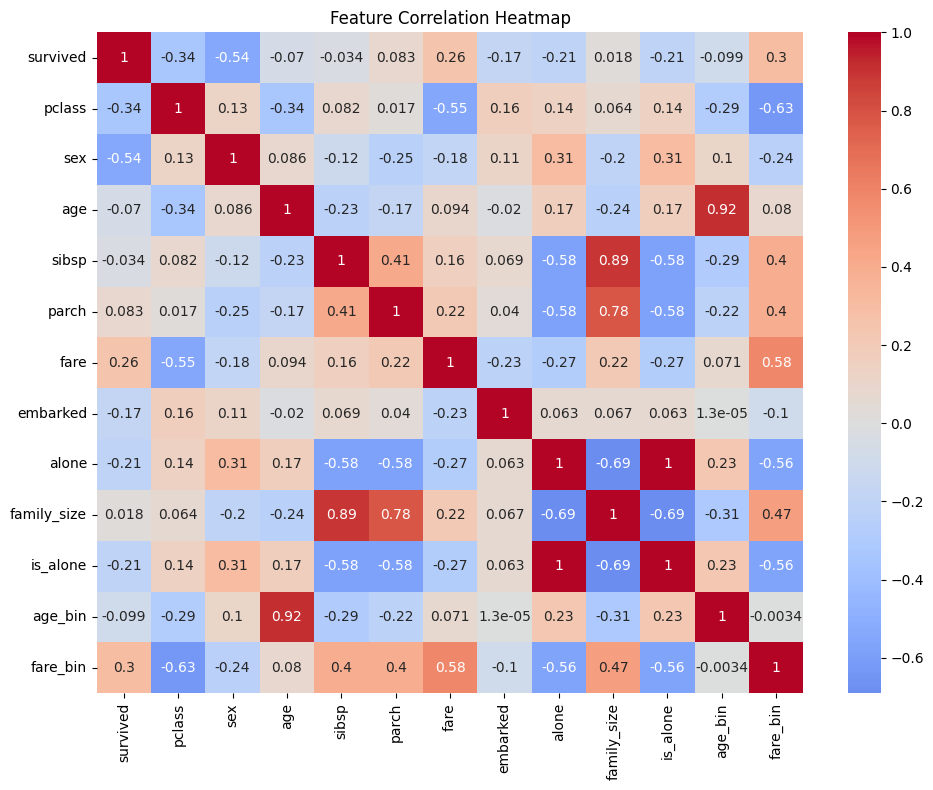

Training set: (711, 12)
Test set: (178, 12)

Class distribution in y_train:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64


In [149]:
# Correlation analysis - see which features matter most
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

# Prepare features
X = df.drop("survived", axis=1)
y = df["survived"]

# Feature Scaling (important for Naive Bayes)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y  # stratify ensures balanced split
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in y_train:\n{y_train.value_counts(normalize=True)}")

In [150]:
# Naive Bayes has 'var_smoothing' as the key hyperparameter
from sklearn.model_selection import GridSearchCV

param_grid = {
    'var_smoothing': np.logspace(-12, -1, 100)  # search over wide range
}

grid_search = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=10,              # 10-fold cross validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best var_smoothing: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# Best model
best_model = grid_search.best_estimator_

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best var_smoothing: {'var_smoothing': np.float64(1e-12)}
Best CV Accuracy: 0.7806


FINAL MODEL EVALUATION

Accuracy:  0.7809
ROC-AUC:   0.8286

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       110
           1       0.72      0.71      0.71        68

    accuracy                           0.78       178
   macro avg       0.77      0.77      0.77       178
weighted avg       0.78      0.78      0.78       178


10-Fold CV Accuracy: 0.7762 (+/- 0.0556)
Individual Folds: ['0.6629', '0.6854', '0.7753', '0.8090', '0.7753', '0.8202', '0.7978', '0.7978', '0.7865', '0.8523']


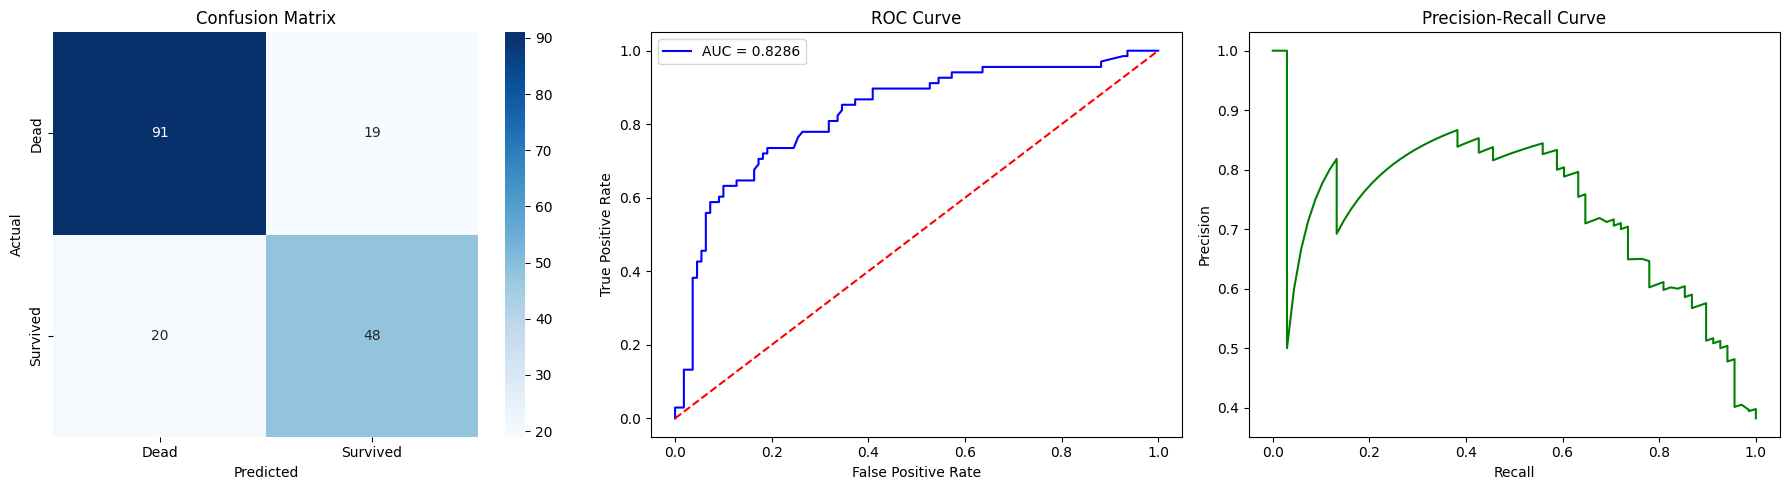

In [151]:
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, precision_recall_curve)

# Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# ---- ALL METRICS ----
print("=" * 50)
print("FINAL MODEL EVALUATION")
print("=" * 50)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# ---- CROSS VALIDATION SCORE ----
cv_scores = cross_val_score(best_model, X_scaled, y, cv=10, scoring='accuracy')
print(f"\n10-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Individual Folds: {[f'{s:.4f}' for s in cv_scores]}")

# ---- CONFUSION MATRIX VISUALIZATION ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Dead', 'Survived'], yticklabels=['Dead', 'Survived'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, 'b-', label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.4f}')
axes[1].plot([0, 1], [0, 1], 'r--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Plot 3: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(recall, precision, 'g-')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150)
plt.show()

In [152]:
import joblib
import pickle

# Method 1: Joblib (recommended for sklearn)
joblib.dump(best_model, 'naive_bayes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

# Save feature names
feature_names = list(X.columns)
joblib.dump(feature_names, 'feature_names.pkl')

print("✅ Model saved successfully!")

# Test loading
loaded_model = joblib.load('naive_bayes_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
test_pred = loaded_model.predict(X_test)
print(f"✅ Loaded model accuracy: {accuracy_score(y_test, test_pred):.4f}")

✅ Model saved successfully!
✅ Loaded model accuracy: 0.7809


In [ ]:
Avyas524@12